In [3]:
import pandas as pd

df = pd.read_excel('base.xlsx')
df.head()

,Номер студента,Сумма,Курс,Время
0,437,8950.0,ML про,2026-08-04 09:08:31
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38
3,443,8475.0,Мат анализ,2026-08-04 10:14:38
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06


In [3]:
!pip install openpyxl #прочитать .xlsx


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
print(df.shape)
print(df.info)

(795, 4)
<bound method DataFrame.info of      Номер студента   Сумма                 Курс               Время
0               437  8950.0               ML про 2026-08-04 09:08:31
1               437  7890.0      Аналитика старт 2026-08-04 09:35:00
2               443  8475.0     Линейная алгебра 2026-08-04 10:14:38
3               443  8475.0           Мат анализ 2026-08-04 10:14:38
4               430  8950.0               К ВУЗу 2026-08-04 13:38:06
..              ...     ...                  ...                 ...
790              36  8950.0     Линейная алгебра 2026-09-09 19:26:20
791              36  8950.0           Мат анализ 2026-09-09 19:26:20
792              36  8950.0  Теория вероятностей 2026-09-09 19:26:20
793             407  8950.0     Линейная алгебра 2026-09-09 23:11:20
794             196  9950.0     Линейная алгебра 2026-09-10 06:09:12

[795 rows x 4 columns]>


In [29]:
df['Время'] = pd.to_datetime(df['Время'])

#Проверка пропусков и дубликатов

print("Пропущенные значения:\n", df.isnull().sum())
print("Полные дубликаты строк:", df.duplicated().sum())

orders = df.groupby(['Номер студента', 'Время']).agg(
    courses_count=('Курс', 'count'),
    courses_list=('Курс', list),
    total_amount=('Сумма', 'sum')
).reset_index()

print(f"Всего строк: {len(df)}")
print(f"потенциальных заказов: {len(orders)}")
print(f"Уникальных студентам: {df['Номер студента'].nunique()}") #в датасете 795 записей относятся к 606 уникал. студентам
orders

Пропущенные значения:
 Номер студента    0
Сумма             0
Курс              0
Время             0
dtype: int64
Полные дубликаты строк: 0
Всего строк: 795
потенциальных заказов: 628
Уникальных студентам: 606


,Номер студента,Время,courses_count,courses_list,total_amount
0,1,2026-09-04 19:30:57,1,[Аналитика старт],8950.0
1,2,2026-09-05 16:22:48,1,[ML про],8950.0
2,3,2026-09-03 22:47:02,1,[АВ тестам],5975.0
3,4,2026-08-31 15:42:34,1,[AI агенты],8950.0
4,5,2026-08-22 16:19:00,1,[ML про],5750.0
...,...,...,...,...,...
623,602,2026-09-05 17:42:39,1,[Backend про],8450.0
624,603,2026-08-18 16:34:39,1,[Аналитика старт],8745.0
625,604,2026-09-06 19:17:57,1,[Аналитика старт],8950.0
626,605,2026-08-26 07:26:53,1,[Алгоритмы про],8950.0


In [8]:
#распределение покупок по студентам
#насколько много у нас клиентов с несколькими курсами

df['Номер студента'].value_counts().value_counts().sort_index()

count
1    443
2    146
3     11
4      3
5      3
Name: count, dtype: int64

In [31]:
#Найдем студентов, у которых несколько строк в одно и то же время

multi_course_orders = orders[orders['courses_count'] > 1]

multi_course_orders.head(15)

,Номер студента,Время,courses_count,courses_list,total_amount
7,8,2026-08-08 16:25:39,2,"[АВ тестам, Алгоритмы]",8990.0
15,16,2026-08-10 16:56:42,2,"[ML старт, Алгоритмы старт]",9900.0
18,19,2026-08-09 11:01:50,2,"[Алгоритмы старт, Аналитика старт]",9900.0
19,20,2026-09-06 11:07:00,2,"[Аналитика про, Аналитика старт]",14950.0
20,21,2026-08-10 16:29:36,2,"[Алгоритмы старт, Аналитика старт]",9900.0
26,26,2026-08-31 14:03:44,2,"[Backend про, Дискретка]",17950.0
28,28,2026-09-04 15:15:34,2,"[Аналитика про, Аналитика старт]",14950.0
33,33,2026-08-08 16:26:36,2,"[Backend старт, Алгоритмы старт]",9990.0
36,36,2026-09-09 19:26:20,5,"[Алгоритмы, Дискретка, Линейная алгебра, Мат а...",44750.0
43,43,2026-09-05 07:16:30,2,"[АВ тестам, Аналитика старт]",12950.0


In [34]:
#найдем человека, который купил 5 курсов в одно время
multi_course_orders[multi_course_orders['courses_count'] == 5]

,Номер студента,Время,courses_count,courses_list,total_amount
36,36,2026-09-09 19:26:20,5,"[Алгоритмы, Дискретка, Линейная алгебра, Мат а...",44750.0
238,231,2026-09-01 18:08:01,5,"[Алгоритмы, Дискретка, Линейная алгебра, Мат а...",41225.0


In [32]:
#сколько потенциальных заказов содержат несколько курсов
len(multi_course_orders)
#153 многокурсовых заказа и всего 628 заказов: 153/628 примерно 24,4%, то есть четверть заказов содержат 2+ курса

153

In [33]:
#Бандлы из 3+ курсов - редкие, всего 8 заказов
multi_course_orders['courses_count'].value_counts().sort_index()

courses_count
2    145
3      4
4      2
5      2
Name: count, dtype: int64

In [12]:
orders.sort_values("total_amount", ascending=False).head(10)

,Номер студента,Время,courses_count,courses_list,total_amount
36,36,2026-09-09 19:26:20,5,"[Алгоритмы, Дискретка, Линейная алгебра, Мат а...",44750.0
238,231,2026-09-01 18:08:01,5,"[Алгоритмы, Дискретка, Линейная алгебра, Мат а...",41225.0
196,191,2026-08-27 15:11:14,4,"[AI агенты, Алгоритмы, Мат анализ, Теория веро...",29850.0
594,575,2026-08-19 09:21:46,3,"[Алгоритмы старт, Аналитика про, Аналитика старт]",24735.0
621,601,2026-09-04 04:51:49,3,"[AI агенты, ML про, ML старт]",22425.0
300,291,2026-08-06 10:06:16,2,"[Линейная алгебра, Мат анализ]",19900.0
343,334,2026-08-07 11:16:14,2,"[Линейная алгебра, Мат анализ]",19900.0
506,488,2026-08-09 16:36:09,1,[Алгоритмы],19350.0
580,561,2026-09-03 18:55:28,1,[Теория вероятностей],18900.0
528,509,2026-09-07 16:51:31,1,[Теория вероятностей],18900.0


In [13]:
#проверим 4 предмета:
#тут видно аномалию, возможно различия в скидках и условиях, однако не могу проверить, потому что недостаточно данных
orders[orders['courses_count'] == 4].sort_values('total_amount', ascending=False)

,Номер студента,Время,courses_count,courses_list,total_amount
196,191,2026-08-27 15:11:14,4,"[AI агенты, Алгоритмы, Мат анализ, Теория веро...",29850.0
375,366,2026-09-06 15:18:37,4,"[AI агенты, ML про, ML старт, Алгоритмы старт]",8950.0


In [14]:
#сколько потенциальных заказов приходится на одного клиента
customer_orders = orders.groupby('Номер студента').size()
customer_orders.value_counts().sort_index()

1    586
2     19
4      1
Name: count, dtype: int64

In [15]:
#найдем человека, на которого приходится 4 заказа. получили человека с индексом 437
customer_orders[customer_orders == 4]

Номер студента
437    4
dtype: int64

In [27]:
#посмотрим его заказы
print(orders[orders['Номер студента'] == 437]['total_amount'].sum())
orders[orders['Номер студента'] == 437].sort_values('Время')

26790.0


,Номер студента,Время,courses_count,courses_list,total_amount
451,437,2026-08-04 09:08:31,1,[ML про],8950.0
452,437,2026-08-04 09:35:00,1,[Аналитика старт],7890.0
453,437,2026-08-22 08:23:59,1,[AI агенты],8950.0
454,437,2026-08-30 16:16:42,1,[AI агенты],1000.0


In [16]:
#количество клиентов, у которых больше одного потенциального заказа
(customer_orders > 1).sum()
#20 / 606 - примерно 3,3% клиентов имеют более одного потенциального заказа

np.int64(20)

In [35]:
df['Дата'] = df['Время'].dt.date

sales_by_day = df.groupby('Дата').size()

sales_by_day

Дата
2026-08-04     9
2026-08-05     8
2026-08-06     8
2026-08-07     6
2026-08-08    49
2026-08-09    92
2026-08-10    36
2026-08-11    17
2026-08-12    17
2026-08-13     9
2026-08-14    10
2026-08-15     7
2026-08-16     6
2026-08-17     4
2026-08-18     7
2026-08-19     7
2026-08-20     6
2026-08-21     3
2026-08-22    32
2026-08-23    49
2026-08-24    22
2026-08-25    18
2026-08-26    10
2026-08-27    18
2026-08-28     7
2026-08-29    13
2026-08-30    23
2026-08-31    25
2026-09-01    28
2026-09-02    28
2026-09-03    22
2026-09-04    33
2026-09-05    59
2026-09-06    54
2026-09-07    20
2026-09-08     8
2026-09-09    24
2026-09-10     1
dtype: int64

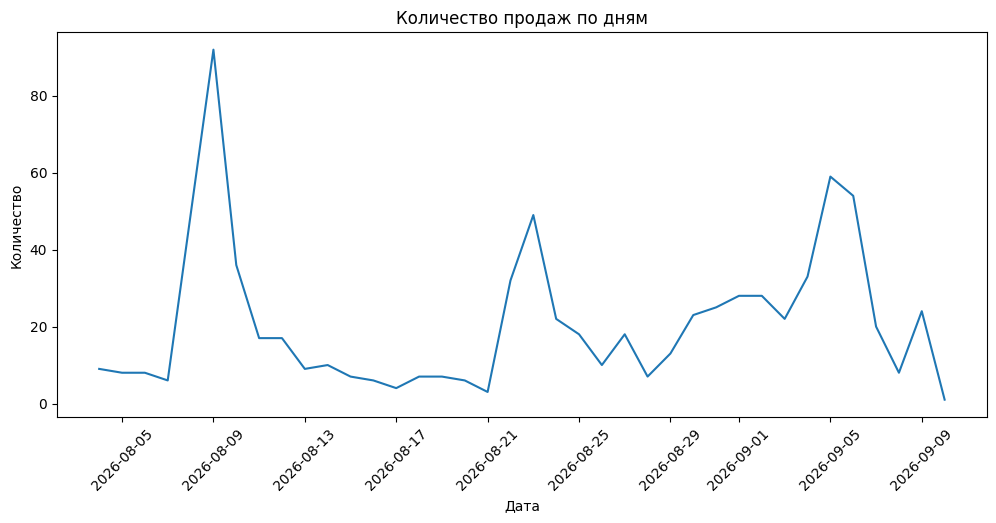

In [37]:
import matplotlib.pyplot as plt

sales_by_day.plot(figsize=(12, 5))

plt.title('Количество продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Продажи распределены неравномерно: наблюдаются пики в отдельные дни. Это может указывать на влияние скидок или маркетинговых активностей

In [ ]:
#Разработка MVP

In [52]:
#Mock данные по переходам и покупкам с рекламных постов
tracking = pd.DataFrame({
    'post_id': [1889, 1890, 1891],
    'clicks': [500, 800, 300],
    'purchases': [15, 10, 20],
    'revenue': [75000, 50000, 120000],
    'cost': [30000, 25000, 40000]
})
tracking

,post_id,clicks,purchases,revenue,cost
0,1889,500,15,75000,30000
1,1890,800,10,50000,25000
2,1891,300,20,120000,40000


In [54]:
#теперь надо объединить с таблицей постов messages.csv

# Объединяем реальные данные о постах с mock-данными по результатам рекламы
messages = pd.read_csv('message.csv')
post_tracking = messages.merge(
    tracking,
    left_on='message_id',
    right_on='post_id',
    how='inner'
)

post_tracking[['message_id', 'date', 'views', 'comments',
               'reactions_total', 'forwards',
               'clicks', 'purchases', 'revenue']]

,message_id,date,views,comments,reactions_total,forwards,clicks,purchases,revenue
0,1891,2026-09-07 10:47:40+00:00,16796,NaN,0,240,300,20,120000
1,1890,2026-09-07 10:47:40+00:00,16940,NaN,0,241,800,10,50000
2,1889,2026-09-07 10:47:40+00:00,16527,NaN,0,240,500,15,75000


In [55]:
#CTR показывает, какая доля людей после просмотра поста перешла по рекламной ссылке
#CTR = clicks / views × 100%
post_tracking['CTR'] = (
    post_tracking['clicks'] / post_tracking['views'] * 100
)

post_tracking[['message_id', 'views', 'clicks', 'CTR']]

,message_id,views,clicks,CTR
0,1891,16796,300,1.786140
1,1890,16940,800,4.722550
2,1889,16527,500,3.025352


In [56]:
#считаем конверсию - процент пользователей, которые купили курс
#Conversion = purchases / clicks × 100% 
post_tracking['Conversion'] = (
    post_tracking['purchases'] / post_tracking['clicks'] * 100
)

post_tracking[['message_id', 'clicks', 'purchases', 'Conversion']]

,message_id,clicks,purchases,Conversion
0,1891,300,20,6.666667
1,1890,800,10,1.250000
2,1889,500,15,3.000000


In [59]:
#считаем эффективность. ROMI
post_tracking = messages.merge(
    tracking,
    left_on='message_id',
    right_on='post_id',
    how='inner'
)
post_tracking['ROMI'] = (
    (post_tracking['revenue'] - post_tracking['cost'])
    / post_tracking['cost'] * 100
)

post_tracking[['message_id', 'cost', 'revenue', 'ROMI']]

,message_id,cost,revenue,ROMI
0,1891,40000,120000,200.0
1,1890,25000,50000,100.0
2,1889,30000,75000,150.0


In [60]:
def find_best_post(df):
    best = df.loc[df['ROMI'].idxmax()]
    return best

best_post = find_best_post(post_tracking)

print('Лучший рекламный пост:', best_post['message_id'])
print('ROMI:', round(best_post['ROMI'], 1), '%')
print('Выручка:', best_post['revenue'])

Лучший рекламный пост: 1891
ROMI: 200.0 %
Выручка: 120000
